In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
from jaxtyping import Float

import dismech_jax as djx

from util import *
from helpers import *
from animate import animate

jax.config.update("jax_enable_x64", True)

In [2]:
from Energy_NN_architectures import *

K_init = jnp.array([2.0, 0.02])

# train_data = "../data/output_train.npz"
# valid_data = "../data/output_train.npz"

# train_data = "../data/combined_output_new_train.npz"
# valid_data = "../data/combined_output_new_test.npz"

train_file = "../experiment_data/directbc_dataset.npz"
valid_file = "../experiment_data/directbc_dataset.npz"

# train_file = "training_data.npz"
# valid_file = "validation_data.npz"
# convert to direct-BC format
# convert_linear_bc_to_direct_bc(train_data, train_file, lambdas=None)
# convert_linear_bc_to_direct_bc(valid_data, valid_file, lambdas=None)


In [3]:
from properties import Properties

properties = Properties(
    length = 0.1,
    r0 = 0.005,
    axs = None,
    jxs = None,
    ixs1 = None,
    ixs2 = None,
    density = 800.0,
    E = 1e6,
    N = 3,
    start = jax.numpy.array([0, 0, 0]),
    end = jax.numpy.array([0.38823935, 0.0, 0.07764297])
)

In [4]:
params = ModelParams(
    der_K=K_init,
    key=jax.random.PRNGKey(42),
    hidden=(10,),
    which_case="MLP",
    corr_factor=1,
    input_mode="raw",
    zero_reference=True,
    activation="tanh",
)
final_model, train_history, valid_history = train_model(properties=properties, model_cls=DiagonalPlusEnergyNN, params=params, train_file=train_file, valid_file=valid_file, n_epochs=500, lr=1e-2)

Epoch 000 | Train: 1.492e-04 | Valid: 1.466e-04
Epoch 010 | Train: 7.740e-05 | Valid: 6.607e-05
Epoch 020 | Train: 4.235e-05 | Valid: 4.266e-05
Epoch 030 | Train: 2.819e-05 | Valid: 2.889e-05
Epoch 040 | Train: 2.503e-05 | Valid: 2.442e-05
Epoch 050 | Train: 2.193e-05 | Valid: 2.137e-05
Epoch 060 | Train: 1.803e-05 | Valid: 1.761e-05
Epoch 070 | Train: 1.404e-05 | Valid: 1.368e-05
Epoch 080 | Train: 1.058e-05 | Valid: 1.029e-05
Epoch 090 | Train: 7.947e-06 | Valid: 7.737e-06
Epoch 100 | Train: 6.224e-06 | Valid: 6.098e-06
Epoch 110 | Train: 5.251e-06 | Valid: 5.184e-06
Epoch 120 | Train: 4.729e-06 | Valid: 4.690e-06
Epoch 130 | Train: 4.388e-06 | Valid: 4.357e-06
Epoch 140 | Train: 4.070e-06 | Valid: 4.037e-06
Epoch 150 | Train: 3.718e-06 | Valid: 3.681e-06
Epoch 160 | Train: 3.330e-06 | Valid: 3.290e-06
Epoch 170 | Train: 2.926e-06 | Valid: 2.885e-06
Epoch 180 | Train: 2.535e-06 | Valid: 2.498e-06
Epoch 190 | Train: 2.186e-06 | Valid: 2.155e-06
Epoch 200 | Train: 1.897e-06 | Valid: 1.

500


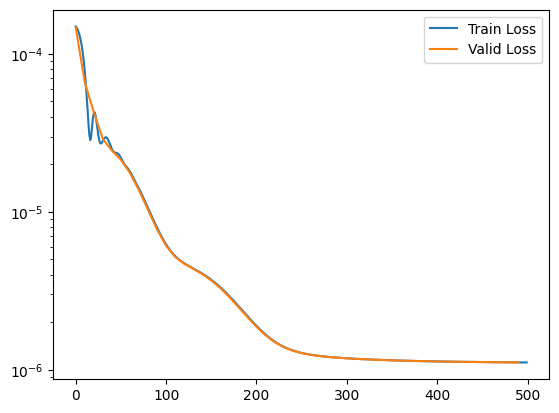

In [5]:
import matplotlib.pyplot as plt
train_np = np.asarray(train_history, dtype=float).reshape(-1)
valid_np = np.asarray(valid_history, dtype=float).reshape(-1)

print(len(train_history))

idx_valid = np.where(valid_np != -1)[0]

plt.plot(np.arange(train_np.size), train_np, label="Train Loss")
plt.plot(idx_valid, valid_np[idx_valid], label="Valid Loss")
plt.yscale("log")
plt.legend()
plt.show()

In [6]:
base, aux = get_slinky(properties)
valid = Dataset.load(valid_file)
print(valid.idx_b)
print(valid.xb)
print(valid.lambdas)



[ 0  1  2  3  7  8  9 10]
[[[0.         0.         0.         0.         0.         0.38823935
   0.         0.07764297]
  [0.         0.         0.         0.         0.         0.39312135
   0.         0.07762597]
  [0.         0.         0.         0.         0.         0.40024235
   0.         0.07688497]
  [0.         0.         0.         0.         0.         0.40510435
   0.         0.07741297]
  [0.         0.         0.         0.         0.         0.40831535
   0.         0.07771397]
  [0.         0.         0.         0.         0.         0.41314735
   0.         0.07731597]
  [0.         0.         0.         0.         0.         0.41956735
   0.         0.07707497]
  [0.         0.         0.         0.         0.         0.42461535
   0.         0.07735197]
  [0.         0.         0.         0.         0.         0.42990835
   0.         0.07727597]
  [0.         0.         0.         0.         0.         0.43300735
   0.         0.07755797]
  [0.         0.        

In [7]:

pred = predict(final_model, base, aux, valid.idx_b, valid.xb, valid.lambdas)

In [8]:
animate(pred[0])

In [9]:
animate(valid.qs[0])

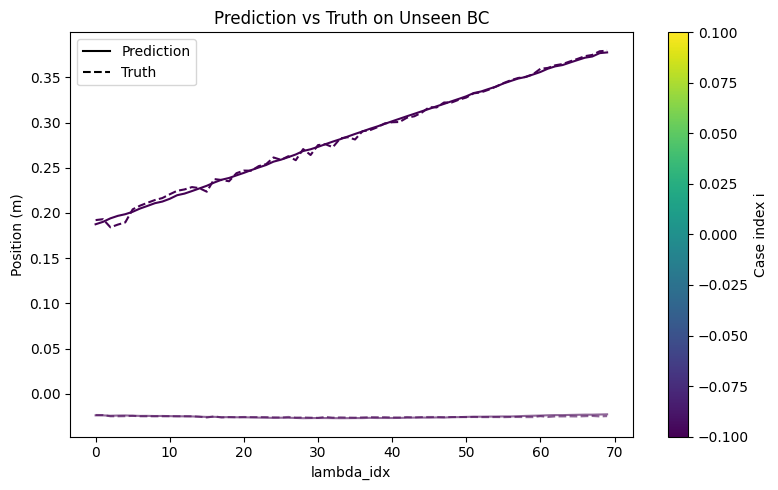

In [10]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.lines as mlines
import jax.numpy as jnp

n_cases = pred.shape[0]
colors = cm.viridis(jnp.linspace(0, 1, n_cases))

fig, ax = plt.subplots(figsize=(8, 5))

for i in range(n_cases):
    c = colors[i]

    # X
    ax.plot(pred[i, :, 4], color=c, linestyle='-')
    ax.plot(valid.qs[i, :, 4], color=c, linestyle='--')

    # Z
    ax.plot(pred[i, :, 6], color=c, linestyle='-', alpha=0.6)
    ax.plot(valid.qs[i, :, 6], color=c, linestyle='--', alpha=0.6)

pred_line = mlines.Line2D([], [], color='black', linestyle='-', label='Prediction')
truth_line = mlines.Line2D([], [], color='black', linestyle='--', label='Truth')
ax.legend(handles=[pred_line, truth_line])

sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=0, vmax=n_cases - 1))
sm.set_array([])  # helps matplotlib know this is a valid mappable
fig.colorbar(sm, ax=ax, label='Case index i')

ax.set_title("Prediction vs Truth on Unseen BC")
ax.set_xlabel("lambda_idx")
ax.set_ylabel("Position (m)")
fig.tight_layout()
plt.show()